# 01 — Análise Exploratória de Dados (EDA)

**Projeto:** Financial Behavior Intelligence  
**Objetivo:** Entender a estrutura do dataset, tratar inconsistências e extrair estatísticas descritivas sobre o comportamento financeiro dos usuários.

---

## 0. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Leitura e Inspeção Inicial

In [2]:
df = pd.read_csv('../data/raw/personal_transactions_padronizado_v2.csv')
print('Shape:', df.shape)
print('\nPrimeiras linhas:')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/personal_transactions_padronizado_v2.csv'

In [ ]:
print('Tipos de dados:')
print(df.dtypes)
print('\nValores nulos:')
print(df.isnull().sum())

Tipos de dados:
User_ID              object
Date                 object
Description          object
Amount              float64
Transaction Type     object
Category             object
Account Name         object
dtype: object

Valores nulos:
User_ID             0
Date                0
Description         0
Amount              0
Transaction Type    0
Category            0
Account Name        0
dtype: int64


## 2. Limpeza e Padronização

In [ ]:
# converter Date para datetime
df['Date'] = pd.to_datetime(df['Date'])

# extrair dimensões temporais
df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%b')
df['Period']     = df['Date'].dt.to_period('M')

# padronizar Account Name (lowercase + agrupar variações)
df['Account Name'] = df['Account Name'].str.lower().str.strip()
df['Account Name'] = df['Account Name'].replace({
    'platinum card': 'credit card',
    'silver card'  : 'credit card'
})

print('Contas após padronização:', df['Account Name'].unique())
print('Shape após limpeza:', df.shape)

df.head()

Contas após padronização: ['credit card' 'checking']
Shape após limpeza: (19046, 11)


,User_ID,Date,Description,Amount,Transaction Type,Category,Account Name,Year,Month,Month_Name,Period
0,USER_0001,2018-01-01,Amazon,11.11,debit,Shopping,credit card,2018,1,Jan,2018-01
1,USER_0001,2018-01-02,Mortgage Payment,1247.44,debit,Mortgage & Rent,checking,2018,1,Jan,2018-01
2,USER_0001,2018-01-02,Thai Restaurant,24.22,debit,Restaurants,credit card,2018,1,Jan,2018-01
3,USER_0001,2018-01-03,Credit Card Payment,2298.09,credit,Credit Card Payment,credit card,2018,1,Jan,2018-01
4,USER_0001,2018-01-04,Netflix,11.76,debit,Movies & DVDs,credit card,2018,1,Jan,2018-01


## 3. Visão Geral do Dataset

In [ ]:
print(f'Período coberto: {df["Date"].min().date()} -> {df["Date"].max().date()}')
print(f'Usuários únicos: {df["User_ID"].nunique()}')
print(f'Total de transações: {len(df):,}')
print(f'\nDistribuição por tipo de transação:')
print(df['Transaction Type'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Período coberto: 2018-01-01 -> 2024-12-19
Usuários únicos: 51
Total de transações: 19,046

Distribuição por tipo de transação:
Transaction Type
debit     93.1%
credit     6.9%
Name: proportion, dtype: object


In [ ]:
# estatísticas descritivas do Amount por tipo
stats = df.groupby('Transaction Type')['Amount'].describe()

# estatísticas descritivas total
total = df['Amount'].describe().to_frame().T
total.index = ['Total'] 

df_final = pd.concat([stats, total]).round(2)
df_final


,count,mean,std,min,25%,50%,75%,max
credit,1318.0,3963.99,1485.95,9.43,3286.38,4057.63,4908.62,7317.64
debit,17728.0,256.36,371.29,1.00,61.27,117.92,264.50,9200.00
Total,19046.0,512.94,1080.04,1.00,64.16,132.57,327.23,9200.00


## 4. Análise de Categorias

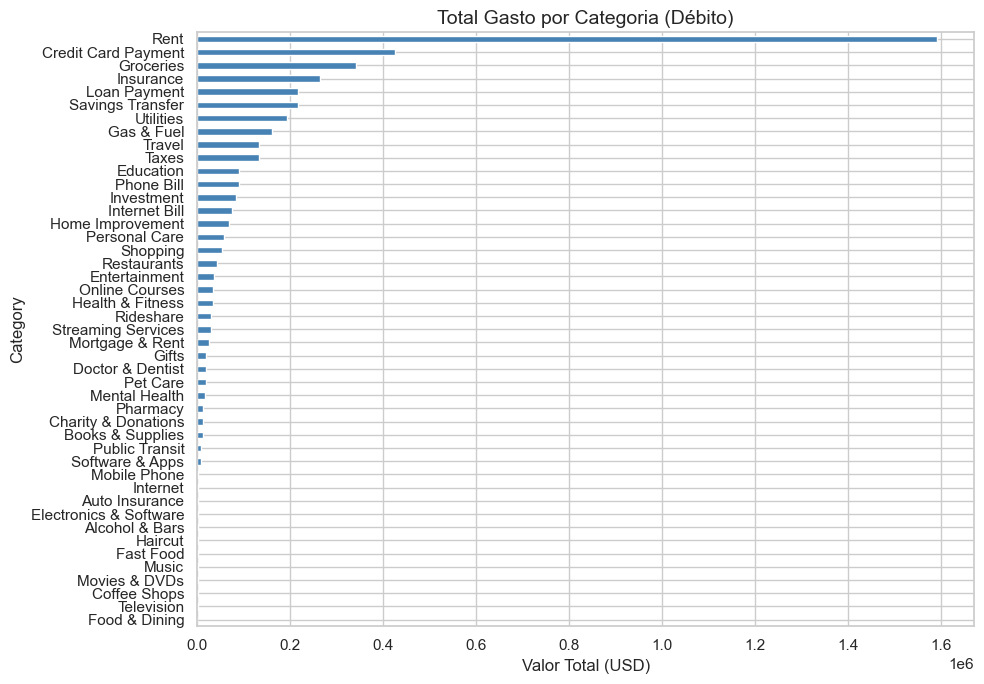

In [ ]:
# total gasto por categoria (débito)
top_cat = (df[df['Transaction Type'] == 'debit']
           .groupby('Category')['Amount']
           .sum()
           .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 7))
top_cat.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Total Gasto por Categoria (Débito)', fontsize=14)
ax.set_xlabel('Valor Total (USD)')
plt.tight_layout()
plt.show()

> **Nota:** Este gráfico inclui todas as categorias de débito, inclusive movimentações financeiras internas
> (`Credit Card Payment`, `Savings Transfer`, `Transfer`, `Investment`). Essas categorias não representam
> consumo real, são transferências entre contas do próprio usuário.
> No **notebook 03**, essas categorias são excluídas para calcular o **gasto real** de cada usuário.
> Excluindo-as, `Rent` se consolida como disparado o maior gasto (35% do total).


## 5. Análise Temporal

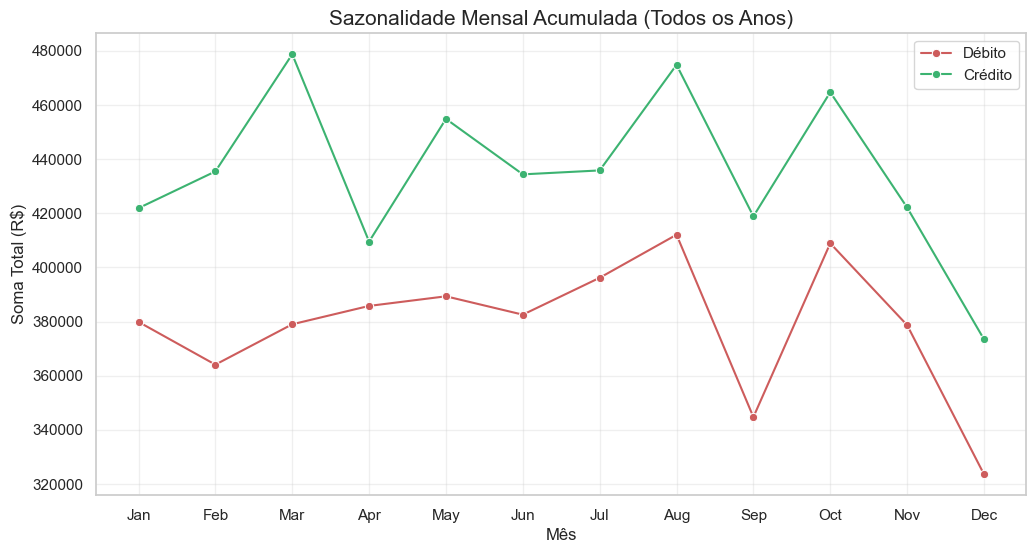

In [ ]:
# evolução mensal de débitos e créditos (agregado todos usuários)
# Month_Name ordenado cronologicamente (não alfabético)
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

monthly_seasonal = (df.groupby(['Month', 'Month_Name', 'Transaction Type'])['Amount']
                      .sum()
                      .unstack(fill_value=0)
                      .reset_index()
                      .sort_values('Month'))

monthly_seasonal['Month_Name'] = pd.Categorical(
    monthly_seasonal['Month_Name'], categories=MONTH_ORDER, ordered=True
)
monthly_seasonal = monthly_seasonal.sort_values('Month_Name')

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_seasonal, x='Month_Name', y='debit',  marker='o', label='Débito',  color='indianred')
sns.lineplot(data=monthly_seasonal, x='Month_Name', y='credit', marker='o', label='Crédito', color='mediumseagreen')

plt.title('Sazonalidade Mensal Acumulada (Todos os Anos)', fontsize=15)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Soma Total (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# agosto = maior gasto | dezembro = menor gasto
pico = monthly_seasonal.loc[monthly_seasonal['debit'].idxmax(), 'Month_Name']
vale = monthly_seasonal.loc[monthly_seasonal['debit'].idxmin(), 'Month_Name']
dif  = (monthly_seasonal['debit'].max() / monthly_seasonal['debit'].min() - 1) * 100
print(f'Maior gasto: {pico} | Menor gasto: {vale} | Diferença: {dif:.1f}%')

**Sazonalidade dos gastos ao longo do ano:**
- Mês de **maior gasto: Agosto** (US$ 412.069)
- Mês de **menor gasto: Dezembro** (US$ 323.622)
- Diferença pico vs vale: **27,3%**
- Gastos se mantêm relativamente estáveis de Janeiro a Julho, com aceleração no segundo semestre

> Diferente do esperado, Dezembro não é o mês mais pesado.
> O pico em Agosto pode estar associado a viagens de férias de verão e pagamentos anuais.

## 6. Análise por Usuário — Saldo Mensal

In [ ]:
# saldo mensal por usuário (crédito - débito)
monthly_user = df.pivot_table(
    index=['User_ID', 'Period'],
    columns='Transaction Type',
    values='Amount',
    aggfunc='sum',
    fill_value=0
).reset_index()

monthly_user.columns.name = None
monthly_user['Saldo'] = monthly_user.get('credit', 0) - monthly_user.get('debit', 0)

print('Saldo médio por usuário (top 10):')
monthly_user.groupby('User_ID')['Saldo'].mean().sort_values(ascending=False).head(10)

Saldo médio por usuário (top 10):


User_ID
USER_0049    4336.272917
USER_0014    4064.026250
USER_0009    3971.345833
USER_0044    3640.220000
USER_0015    3610.367500
USER_0050    3270.041250
USER_0039    3201.097917
USER_0042    2607.646667
USER_0021    2596.392083
USER_0008    2390.999583
Name: Saldo, dtype: float64

In [ ]:
# usuários com mais meses de saldo negativo
neg_balance = (monthly_user[monthly_user['Saldo'] < 0]
               .groupby('User_ID')
               .size()
               .sort_values(ascending=False))

print('Top 10 usuários com mais meses de saldo negativo:')
print(neg_balance.head(10))

Top 10 usuários com mais meses de saldo negativo:
User_ID
USER_0016    24
USER_0041    24
USER_0031    24
USER_0035    24
USER_0026    24
USER_0007    23
USER_0025    22
USER_0032    22
USER_0038    21
USER_0029    21
dtype: int64




> O padrão de saldo negativo recorrente não é acidental, é comportamental.
> Esses usuários serão identificados como "Em Risco Financeiro" no notebook 04.

## 7. Estatísticas Descritivas Consolidadas por Usuário

> Estas métricas serão expandidas e usadas como features no notebook `03_feature_engineering`.

In [ ]:
user_stats = monthly_user.groupby('User_ID').agg(
    media_saldo        = ('Saldo', 'mean'),
    mediana_saldo      = ('Saldo', 'median'),
    desvio_saldo       = ('Saldo', 'std'),
    meses_negativo     = ('Saldo', lambda x: (x < 0).sum()),
    total_meses        = ('Saldo', 'count')
).reset_index()

user_stats['pct_meses_negativo'] = ( # porcentagem de tempo que o usuario ficou negativo 
    user_stats['meses_negativo'] / user_stats['total_meses']
).round(3)

user_stats.round(2)

,User_ID,media_saldo,mediana_saldo,desvio_saldo,meses_negativo,total_meses,pct_meses_negativo
0,USER_0001,1342.19,1947.72,3065.70,3,21,0.14
1,USER_0002,1043.80,978.48,2537.82,4,24,0.17
2,USER_0003,-242.43,-112.70,1670.35,17,24,0.71
3,USER_0004,406.69,314.33,1338.02,5,24,0.21
4,USER_0005,2105.64,2015.99,1873.79,2,24,0.08
5,USER_0006,1231.26,1051.18,1142.07,1,24,0.04
6,USER_0007,-2820.42,-2558.45,1513.98,23,24,0.96
7,USER_0008,2391.00,2364.61,3039.47,3,24,0.12
8,USER_0009,3971.35,3867.21,2239.37,1,24,0.04
9,USER_0010,1666.60,1558.06,2663.12,4,24,0.17


## 8. Sazonalidade — Gastos por Mês do Ano

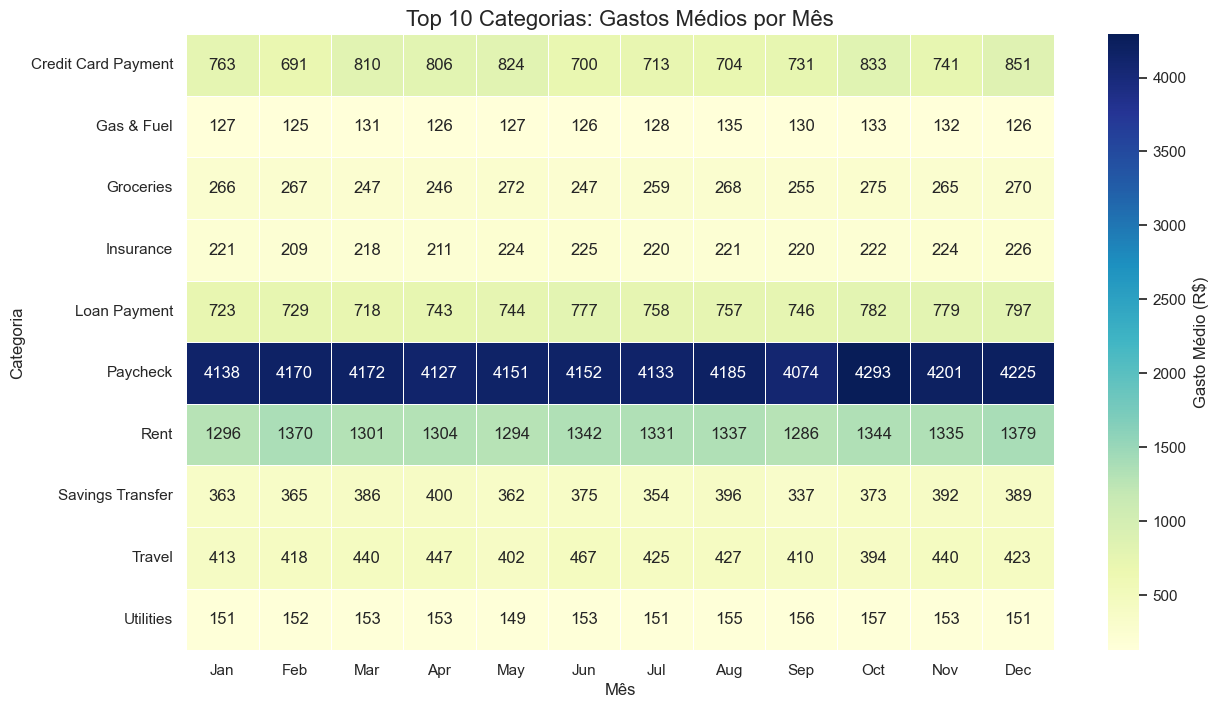

In [ ]:
# heatmap do top 10 gastos médios por mês (eixo x) e categoria (eixo y)

top_categories = df.groupby('Category')['Amount'].sum().nlargest(10).index

# matriz de dados
heatmap_data_top = df[df['Category'].isin(top_categories)].pivot_table(
    index='Category', 
    columns='Month_Name', 
    values='Amount', 
    aggfunc='mean'
).reindex(columns=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data_top, 
    annot=True,     
    fmt=".0f",      
    cmap="YlGnBu",  
    linewidths=.5,  
    cbar_kws={'label': 'Gasto Médio (R$)'}
)

plt.title('Top 10 Categorias: Gastos Médios por Mês', fontsize=16)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Categoria', fontsize=12)

plt.show()


## 9. Salvar Dataset Tratado

In [ ]:
df.to_csv('../data/processed/transactions_clean.csv', index=False)
print('Salvo em data/processed/transactions_clean.csv')

Salvo em data/processed/transactions_clean.csv
